In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 8.7 MB/s eta 0:00:00


# Part 1: Classification section

## load (CBC dataset)

In [2]:
# load & inspect  CBC data
data = pd.read_csv('/content/CBC.csv')
data.head(50)

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeoBks,ItalCook,ItalAtlas,ItalArt,Florence,Related purchase
0,1,25,1,297,14,2,22,0,1,1,0,0,0,0,0,0,0,0,0
1,2,29,0,128,8,2,10,0,0,0,0,0,0,0,0,0,0,0,0
2,3,46,1,138,22,7,56,2,1,2,0,1,0,1,1,0,0,0,2
3,4,47,1,228,2,1,2,0,0,0,0,0,0,0,0,0,0,0,0
4,5,51,1,257,10,1,10,0,0,0,0,0,0,0,0,0,0,0,0
5,6,60,1,145,6,2,12,0,0,0,0,0,0,0,0,0,0,0,0
6,7,61,1,190,16,1,16,0,0,0,0,0,0,1,0,0,0,0,1
7,8,79,1,187,14,1,14,1,0,0,0,0,0,0,0,0,0,0,0
8,9,81,1,252,10,1,10,0,0,0,0,0,0,0,0,0,0,0,0
9,10,90,1,240,6,3,20,0,0,1,0,0,0,0,0,0,0,0,0


In [3]:
# drop cols that are not useful for predictions
drop_cols = ["Seq#", "ID#"]
data = data.drop(columns=drop_cols)

In [4]:
# preprocessing - check missing vals
missing_counts = data.isnull().sum()
print("Missing values per column:")
print(missing_counts)

Missing values per column:
Gender              0
M                   0
R                   0
F                   0
FirstPurch          0
ChildBks            0
YouthBks            0
CookBks             0
DoItYBks            0
RefBks              0
ArtBks              0
GeoBks              0
ItalCook            0
ItalAtlas           0
ItalArt             0
Florence            0
Related purchase    0
dtype: int64


In [5]:
# check for outliers (made two helper functions using 2 methods from prev homework)
def identify_outliers_iqr(df, column):
    """Identifies outliers in a column using the IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column].tolist()
    return outliers

def identify_outliers_zscore(df, column, threshold=3):
    """Identifies outliers in a column using the Z-score method."""
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    outliers = df[abs(z_scores) > threshold][column].tolist()
    return outliers

numeric_cols = data.select_dtypes(include=np.number).columns

outliers_iqr = {}
outliers_zscore = {}

for col in numeric_cols:
    outliers_iqr[col] = identify_outliers_iqr(data, col)
    outliers_zscore[col] = identify_outliers_zscore(data, col)

print("Outliers identified by IQR method:")
print(outliers_iqr)
print("\nOutliers identified by Z-score method:")
print(outliers_zscore)

Outliers identified by IQR method:
{'Gender': [], 'M': [], 'R': [34, 32, 36, 30, 30, 34, 36, 30, 32, 32, 30, 34, 32, 32, 36, 32, 34, 32, 30, 30, 36, 32, 32, 34, 36, 34, 34, 32, 30, 34, 32, 32, 32, 34, 30, 36, 36, 34, 30, 32, 32, 30, 36, 32, 36, 34, 36, 34, 30, 32, 30, 32, 32, 34, 30, 34, 34, 34, 34, 30, 32, 34, 30, 34, 36, 32, 34, 32, 32, 30, 34, 34, 30, 32, 30, 32, 32, 34, 34, 30, 32, 32, 32, 32, 32, 30, 32, 34, 30, 32, 30, 32, 30, 36, 32, 34, 34, 32, 30, 30, 30, 36, 34, 34, 30, 30, 34, 30, 30, 30, 36, 30, 32, 34, 34, 36, 36, 30, 30, 32, 30, 32, 30, 30, 32, 36, 30, 30, 30, 34, 30, 32, 32, 36, 32, 34, 32, 30, 34, 32, 30, 36, 36, 30, 32, 34, 36, 30, 36, 30, 32, 34, 30, 30, 32, 32, 36, 34, 34, 32, 34, 30, 32, 34, 34, 30, 34, 30, 32, 34, 30, 32, 32, 30, 36, 32, 32, 32, 32, 30, 32, 34, 32, 32, 32, 32, 30, 34, 34, 34, 34, 34, 34, 34, 36, 30, 36, 30, 30, 32, 36, 36, 32, 30, 36, 30, 30, 34, 30, 34, 34, 30, 30, 34, 30, 34, 30, 32, 36, 30, 36, 36, 30, 32, 32, 30, 36, 34, 30, 32, 34, 34, 34, 32,

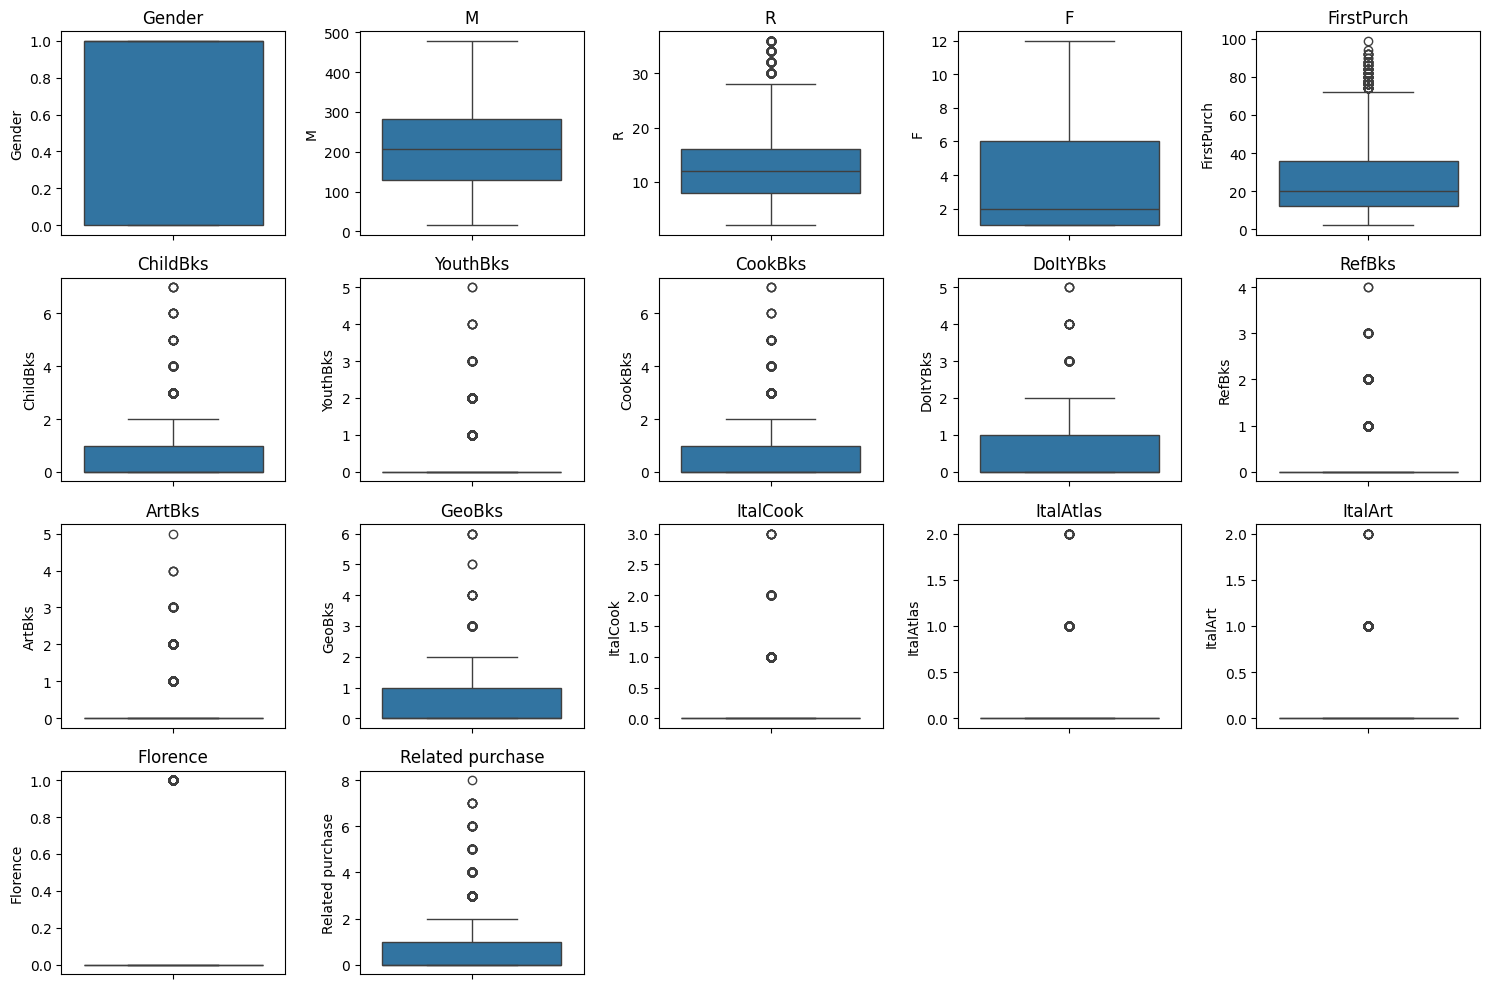

In [6]:
# plot distribution of outliers
numeric_cols = data.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 5, i + 1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**note on outliers**
I decided to keep them Outliers in spending (M), frequency (F), or categories are real customer behavior, not data errors. Additionally removing high-spending customers would actually remove valuable signal. One final note logistic regression and random forest (both of which I plan to use) are robust to moderate outliers so this will likly not be an issue.

In [7]:
# Separate features (X) and target (y)
df = pd.DataFrame(data)

X = df.drop('Florence', axis=1)
y = df['Florence']

print("Features (X):")
print(X)
print("\nTarget (y):")
print(y)

Features (X):
      Gender    M   R  F  FirstPurch  ChildBks  YouthBks  CookBks  DoItYBks  \
0          1  297  14  2          22         0         1        1         0   
1          0  128   8  2          10         0         0        0         0   
2          1  138  22  7          56         2         1        2         0   
3          1  228   2  1           2         0         0        0         0   
4          1  257  10  1          10         0         0        0         0   
...      ...  ...  .. ..         ...       ...       ...      ...       ...   
3995       0  141   2  2           6         0         0        0         0   
3996       1  357  16  9          52         1         1        2         2   
3997       0   48  12  1          12         0         0        0         0   
3998       0  214  14  7          38         1         1        3         1   
3999       1  114  10  2          12         0         0        0         0   

      RefBks  ArtBks  GeoBks  ItalCoo

In [8]:
# check for imbalance of Y | after runnign first time  i noticed the miniority class was not getting factored
print("Class balance in the target variable (Florence):")
print(y.value_counts())
print("\nPercentages:")
print(y.value_counts(normalize=True) * 100)

Class balance in the target variable (Florence):
Florence
0    3662
1     338
Name: count, dtype: int64

Percentages:
Florence
0    91.55
1     8.45
Name: proportion, dtype: float64


In [9]:
# split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Original dataset size: {len(X)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Scale the numeric features
numeric_cols = X_train.select_dtypes(include=np.number).columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_scaled[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val_scaled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_scaled[numeric_cols])

print("\nScaled Training Features (X_train_scaled):")
display(X_train_scaled.head())
print("\nScaled Validation Features (X_val_scaled):")
display(X_val_scaled.head())
print("\nScaled Test Features (X_test_scaled):")
display(X_test_scaled.head())

Original dataset size: 4000
Training set size: 2400 (60.0%)
Validation set size: 800 (20.0%)
Test set size: 800 (20.0%)

Scaled Training Features (X_train_scaled):


,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeoBks,ItalCook,ItalAtlas,ItalArt,Related purchase
1494,0.641689,-1.856442,-0.410523,-0.823102,-0.890772,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
353,0.641689,2.146659,0.572275,1.489051,1.591401,2.323192,-0.494206,3.844329,0.921051,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
1232,0.641689,-1.625687,-0.656223,-0.823102,-0.998692,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
613,0.641689,0.280551,-0.656223,2.356108,0.943877,0.347409,1.185815,1.138907,-0.509708,4.864882,2.824050,-0.496825,-0.317478,-0.176267,-0.210494,0.902343
3506,-1.558387,1.966068,0.326576,2.356108,1.483480,0.347409,1.185815,0.237100,6.644088,-0.454351,-0.490238,2.141182,-0.317478,-0.176267,-0.210494,0.902343



Scaled Validation Features (X_val_scaled):


,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeoBks,ItalCook,ItalAtlas,ItalArt,Related purchase
3823,0.641689,-0.311386,0.080876,0.043955,-0.027407,1.335300,-0.494206,-0.664707,0.921051,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
1832,0.641689,-0.231123,-0.901922,-0.534083,-0.998692,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
3301,-1.558387,-1.184242,0.080876,0.043955,0.296354,-0.640483,-0.494206,1.138907,0.921051,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
1862,0.641689,-0.231123,0.817975,0.043955,0.620116,-0.640483,1.185815,0.237100,0.921051,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
3047,0.641689,-0.351517,1.309374,1.200031,1.591401,1.335300,-0.494206,1.138907,3.782570,1.318727,1.166906,-0.496825,2.291933,-0.176267,-0.210494,0.902343



Scaled Test Features (X_test_scaled):


,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,DoItYBks,RefBks,ArtBks,GeoBks,ItalCook,ItalAtlas,ItalArt,Related purchase
2730,0.641689,0.290584,-0.164824,-0.823102,-0.782851,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,3.460185,2.291933,-0.176267,-0.210494,2.510679
1510,0.641689,-0.311386,-1.393322,-0.823102,-1.322454,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
229,0.641689,-1.204308,0.326576,-0.823102,-0.567010,-0.640483,-0.494206,-0.664707,0.921051,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992
2425,0.641689,-1.354801,2.537872,-0.823102,0.404275,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,2.824050,-0.496825,-0.317478,-0.176267,-0.210494,0.902343
543,0.641689,-0.080631,-0.410523,-0.823102,-0.890772,-0.640483,-0.494206,-0.664707,-0.509708,-0.454351,-0.490238,-0.496825,-0.317478,-0.176267,-0.210494,-0.705992


# Preprocessing Review (1.3)

This section summarizes the preprocessing steps used to prepare the CBC dataset for classification. The goal was to ensure data quality, identify potential issues, and structure the data

## 1. Removing Irrelevant features

- The columns Seq# and ID# are unique identifiers and contain no predictive information about whether a customer purchased The Art History of Florence.


## 2. Checking for Missing Values

- Missing values can distort model training or reduce usable data.

**Findings:** No missing values were present in any column.


## 3. Outlier Detection and Interpretation

- Outliers can influence model training, so identifying them helps determine whether they require treatment.

Methods: Both IQR and Z-score methods were applied, and boxplots were generated for visual confirmation.

**Findings:** Several numeric columns contained high-value outliers representing heavy-spending or highly active customers. Outliers were kept, as they reflect real customer behavior. Logistic Regression and Random Forest are sufficiently robust, and removing these values would risk discarding informative patterns.



## 4. Defining features and target variable

- Supervised learning requires separating predictors (X) from the response (y).

 The Florence column was set as the target variable, and all remaining columns were used as features.


## 5. Class Imbalance Assessment

- The target variable was suspected to be imbalanced, which can bias models toward the majority class.

**Findings:** The dataset was heavily imbalanced (91.55% class 0, 8.45% class 1).
Since imbalance affects most metrics—especially. Accuracy techniques such as SMOTE oversampling and class-weighted models were incorporated during training.

## 6. Train/Validation/Test Split
- the data was split into 60% training, 20% validation, and 20% test.


## 7. Scaling Numeric Features

-  Models like Logistic Regression rely on feature magnitude scaling stabilizes optimization and prevents large-valued features from dominating.

**Method:** StandardScaler was fit on the training set and applied to validation and test sets to avoid data leakage.  All numeric features were standardized, improving training stability and preparing the data for algorithms sensitive to feature scales.

## Define & train model 1 (LR no SMOTE)

I Plan to test two models logistic regression & Random Forest classifiers, a abseline version and another with SMOTE upsampling to see if that is able to help with the class imbalance.

In [10]:
# this is a grid search i ran the results are not too different from the abse version uncomment if you want to test it

# # define the parameter grid
# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear', 'saga'],
#     'class_weight': ['balanced', None],
#     'max_iter': [5000]}

# base_model = LogisticRegression(random_state=42)

# # GridSearchCV
# grid_search = GridSearchCV(
#     estimator=base_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=-1,
#     verbose=2)

# # fit the grid search
# print("Starting grid search...")
# grid_search.fit(X_train_scaled, y_train)


# print(f"\nBest parameters: {grid_search.best_params_}")
# print(f"Best cross-validation ROC AUC score: {grid_search.best_score_:.4f}")

# # use the best model to make predictions
# best_model = grid_search.best_estimator_
# predictions = best_model.predict(X_test_scaled)
# probabilities = best_model.predict_proba(X_test_scaled)[:, 1]

# # evaluate the best model
# accuracy = accuracy_score(y_test, predictions)
# print(f"\nTest Set Accuracy: {accuracy:.4f}")

# auc_score = roc_auc_score(y_test, probabilities)
# print(f"Test Set ROC AUC Score: {auc_score:.4f}")

# print("\nClassification Report:")
# print(classification_report(y_test, predictions))

In [11]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    random_state=42,
    max_iter=5000,
    class_weight='balanced')

# train on scaled training data
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

# get probabilities for the positive class (class 1)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")

auc_score = roc_auc_score(y_test, probabilities)
print(f"ROC AUC Score: {auc_score:.4f}")

print("\nClassification Report (Default Threshold 0.5):")
print(classification_report(y_test, predictions))

Accuracy: 0.6538
ROC AUC Score: 0.6384

Classification Report (Default Threshold 0.5):
              precision    recall  f1-score   support

           0       0.94      0.66      0.78       729
           1       0.14      0.56      0.22        71

    accuracy                           0.65       800
   macro avg       0.54      0.61      0.50       800
weighted avg       0.87      0.65      0.73       800



In [12]:
# results are not good so we can use SMOTE to upsample and retest the model
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("Original training size:", X_train.shape)
print("Resampled training size:", X_train_res.shape)
print("Original class distribution:", np.bincount(y_train))
print("Resampled class distribution:", np.bincount(y_train_res))


Original training size: (2400, 16)
Resampled training size: (4402, 16)
Original class distribution: [2201  199]
Resampled class distribution: [2201 2201]


In [13]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=4)

model.fit(X_train_res, y_train_res)

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, predictions)
auc_score = roc_auc_score(y_test, probabilities)

print("Accuracy:", accuracy)
print("AUC:", auc_score)


Accuracy: 0.6525
AUC: 0.6360922738074537


## Define & train model 2 (CLF, no SMOTE)

In [14]:
# Base Random Forest (scaled data)
clf_base = RandomForestClassifier(max_depth=None, random_state=42)

clf_base.fit(X_train_scaled, y_train)

y_pred_base = clf_base.predict(X_test_scaled)
probs_base = clf_base.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest (No SMOTE) ===")
print(classification_report(y_test, y_pred_base))

auc_base = roc_auc_score(y_test, probs_base)
print(f"AUC: {auc_base:.4f}")


=== Random Forest (No SMOTE) ===
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       729
           1       0.23      0.04      0.07        71

    accuracy                           0.90       800
   macro avg       0.57      0.51      0.51       800
weighted avg       0.85      0.90      0.87       800

AUC: 0.6224


In [15]:
# Random Forest on SMOTE-resampled data
clf_smote = RandomForestClassifier(max_depth=None, random_state=42)

clf_smote.fit(X_train_res, y_train_res)

y_pred_smote = clf_smote.predict(X_test_scaled)
probs_smote = clf_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest (With SMOTE) ===")
print(classification_report(y_test, y_pred_smote))

auc_smote = roc_auc_score(y_test, probs_smote)
print(f"AUC: {auc_smote:.4f}")



=== Random Forest (With SMOTE) ===
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       729
           1       0.15      0.07      0.10        71

    accuracy                           0.88       800
   macro avg       0.53      0.52      0.52       800
weighted avg       0.85      0.88      0.86       800

AUC: 0.5893


# Summary of Model Performance (also part of requirements of  section 1.3)

This section compares the performance of Logistic Regression and Random Forest models under both baseline and SMOTE-augmented conditions. Because the target variable (Florence) is highly imbalanced (8.45% positive cases), both AUC and minority-class performance are emphasized over raw accuracy.


**1. Logistic Regression (Baseline)**

- Accuracy: 0.6538
- AUC: 0.6384

Baseline Logistic Regression provides the strongest AUC among all tested models. Although overall accuracy is modest, this is expected due to the class imbalance. The AUC of ~0.64 indicates meaningful discriminatory ability between buyers and non-buyers.


**2. Logistic Regression with SMOTE**

- Accuracy: 0.6525
- AUC: 0.6361

Applying SMOTE slightly altered the model’s performance but did not significantly improve or harm AUC. This is common when logistic regression coefficients already generalize well to the minority class. Accuracy remains essentially unchanged compared to baseline.


**3. Random Forest (Baseline)**

- Accuracy: 0.90
- AUC: 0.6224

- Precision (Class 1): 0.23
- Recall (Class 1): 0.04
- F1-Score (Class 1): 0.07

The baseline Random Forest achieves high overall accuracy by predicting the majority class (no suprise). Minority-class recall is extremely low, making the model ineffective for identifying true buyers despite its strong performance on class 0.

**4. Random Forest with SMOTE**

- Accuracy: 0.88
- AUC: 0.5893
- Precision (Class 1): 0.15
- Recall (Class 1): 0.07
- F1-Score (Class 1): 0.10

SMOTE improves minority-class recall slightly but decreases AUC. This indicates that oversampling introduces synthetic examples the Random Forest cannot generalize well from.

**Overall Model Comparison**
Model	Accuracy	AUC	Notes
- Logistic Regression (Baseline)	0.6538	0.6384	Best AUC overall; stable and reliable
- Logistic Regression + SMOTE	0.6525	0.6361	Nearly identical to baseline


- Random Forest (Baseline)	0.90	0.6224	High accuracy but fails to find minority class
- Random Forest + SMOTE	0.88	0.5893	Slight recall improvement but lowest AUC


**Best Model Selection**

Based on AUC, which the project specifically requires, baseline Logistic Regression is the strongest-performing model.

# Project PT2 (Spotify music recommendation system)

In [16]:
spotify_data = pd.read_csv('/content/genres.csv')
spotify_data.head(10)

/tmp/ipython-input-1721665129.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  spotify_data = pd.read_csv('/content/genres.csv')


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,...,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,...,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,...,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,...,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,...,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN
5,0.721,0.568,0,-11.295,1,0.4140,0.0452,0.212000,0.1280,0.1090,...,6fsypiJHyWmeINsOLC1cos,spotify:track:6fsypiJHyWmeINsOLC1cos,https://api.spotify.com/v1/tracks/6fsypiJHyWme...,https://api.spotify.com/v1/audio-analysis/6fsy...,112511,4,Dark Trap,Gatteka,NaN,NaN
6,0.718,0.668,8,-4.162,1,0.1370,0.0254,0.007800,0.1240,0.0380,...,0XfQbq7DaMOmVXgQ71eA6E,spotify:track:0XfQbq7DaMOmVXgQ71eA6E,https://api.spotify.com/v1/tracks/0XfQbq7DaMOm...,https://api.spotify.com/v1/audio-analysis/0XfQ...,77584,4,Dark Trap,kamikaze (+ pulse),NaN,NaN
7,0.694,0.711,8,-5.525,1,0.2210,0.0397,0.000000,0.1120,0.2830,...,0LLeuNBWPOg3XA73yab3PT,spotify:track:0LLeuNBWPOg3XA73yab3PT,https://api.spotify.com/v1/tracks/0LLeuNBWPOg3...,https://api.spotify.com/v1/audio-analysis/0LLe...,127524,3,Dark Trap,T.R.U. (Totally Rotten Underground),NaN,NaN
8,0.774,0.751,1,-2.445,1,0.1980,0.0614,0.000000,0.0728,0.1890,...,37gqBnUAZe8BY8WR56kDNk,spotify:track:37gqBnUAZe8BY8WR56kDNk,https://api.spotify.com/v1/tracks/37gqBnUAZe8B...,https://api.spotify.com/v1/audio-analysis/37gq...,140326,4,Dark Trap,I Put My Dick in Your Mental,NaN,NaN
9,0.893,0.907,11,-10.406,1,0.3670,0.1520,0.031100,0.5580,0.3020,...,2ggqfj97qyiORmXoVFzP5j,spotify:track:2ggqfj97qyiORmXoVFzP5j,https://api.spotify.com/v1/tracks/2ggqfj97qyiO...,https://api.spotify.com/v1/audio-analysis/2ggq...,121979,4,Dark Trap,Andromeda,NaN,NaN


In [17]:
spotify_data.info()
spotify_data.describe()
spotify_data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0


In [40]:
drop_cols = ["type", "id", "uri", "track_href", "analysis_url", "song_name", "title", "Unnamed: 0"]

# create a processed DataFrame by dropping identified columns
processed_df = spotify_data.drop(columns=[c for c in drop_cols if c in spotify_data.columns])

# store genre for interpretation later
genre = processed_df["genre"]
features_for_clustering = processed_df.drop(columns=["genre"])

In [41]:

# check missing vals --> no mising vals recorded
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts)

Missing values per column:
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64


In [42]:
# scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_for_clustering)
x_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering.columns)
display(x_scaled_df.head())

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,1.223608,0.280079,-0.919298,-0.305514,0.905517,2.246552,-0.212853,-0.727231,-0.902637,0.136790,0.398876,-1.226992,0.102184
1,0.508480,-1.466185,0.717318,-0.259954,0.905517,-0.453057,1.784518,-0.763370,-0.547231,-0.999586,-1.358564,-0.256796,0.102184
2,1.344924,0.709845,-0.100990,0.572039,0.905517,-0.588592,-0.482135,-0.763359,0.899456,-1.363655,2.959861,-1.476787,0.102184
3,-1.043093,0.100557,-1.464837,0.596860,0.905517,-0.266002,-0.424181,-0.763370,-0.570013,-0.780887,1.655485,-1.235520,-3.624453
4,1.012900,-0.753535,-0.919298,-0.408876,0.905517,1.239945,0.707390,-0.763370,-0.273841,1.003008,0.021554,-1.239046,0.102184


In [43]:
print("Columns in features_for_clustering:")
print(features_for_clustering.columns)

print("\nFirst 5 rows of features_for_clustering:")
display(features_for_clustering.head())

Columns in features_for_clustering:
Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature'],
      dtype='object')

First 5 rows of features_for_clustering:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,124539,4
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,224427,4
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,98821,4
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,123661,3
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,123298,4


In [44]:
# note this takes a long time to run and may crash if on a base runtime!
nan_rows = np.isnan(X_scaled).any(axis=1)
X_scaled_cleaned = X_scaled[~nan_rows]

# K values to test (starting from 2 since silhouette needs at least 2 clusters)
k_range = range(2, 11)

#results
kmeans_silhouette_scores = []
agglomerative_silhouette_scores = []
kmeans_wcss = []

print("Computing optimal K for KMeans...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_scaled_cleaned)

    # calculate / store silhouette score
    silhouette_avg = silhouette_score(X_scaled_cleaned, kmeans_labels)
    kmeans_silhouette_scores.append(silhouette_avg)
    kmeans_wcss.append(kmeans.inertia_)

    print(f"K={k}: Silhouette Score = {silhouette_avg:.4f}")


print("\nComputing optimal K for Agglomerative Clustering...")
for k in k_range:
    # Agglomerative Clustering
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agglo_labels = agglo.fit_predict(X_scaled_cleaned)

    # calculate silhouette score
    silhouette_avg = silhouette_score(X_scaled_cleaned, agglo_labels)
    agglomerative_silhouette_scores.append(silhouette_avg)

    print(f"K={k}: Silhouette Score = {silhouette_avg:.4f}")

# find optimal K for each algorithm
optimal_k_kmeans = k_range[np.argmax(kmeans_silhouette_scores)]
optimal_k_agglo = k_range[np.argmax(agglomerative_silhouette_scores)]

print(f"\nOptimal K for KMeans: {optimal_k_kmeans} (Silhouette Score: {max(kmeans_silhouette_scores):.4f})")
print(f"Optimal K for Agglomerative: {optimal_k_agglo} (Silhouette Score: {max(agglomerative_silhouette_scores):.4f})")


Computing optimal K for KMeans...
K=2: Silhouette Score = 0.1487
K=3: Silhouette Score = 0.1363
K=4: Silhouette Score = 0.1348
K=5: Silhouette Score = 0.1245
K=6: Silhouette Score = 0.1255
K=7: Silhouette Score = 0.1213
K=8: Silhouette Score = 0.1264
K=9: Silhouette Score = 0.1125
K=10: Silhouette Score = 0.1206

Computing optimal K for Agglomerative Clustering...
K=2: Silhouette Score = 0.1200
K=3: Silhouette Score = 0.0997
K=4: Silhouette Score = 0.1039
K=5: Silhouette Score = 0.1023
K=6: Silhouette Score = 0.0919
K=7: Silhouette Score = 0.0946
K=8: Silhouette Score = 0.0845
K=9: Silhouette Score = 0.0719
K=10: Silhouette Score = 0.0626

Optimal K for KMeans: 2 (Silhouette Score: 0.1487)
Optimal K for Agglomerative: 2 (Silhouette Score: 0.1200)


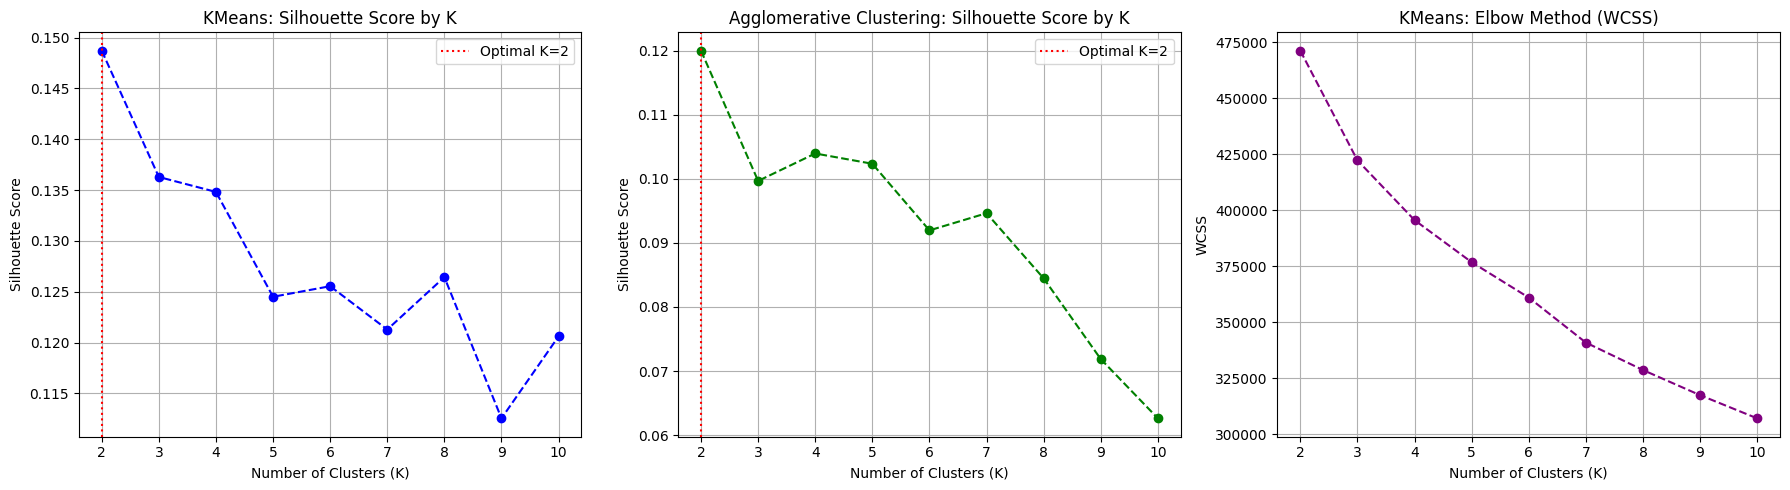

In [34]:
# plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: KMeans Silhouette Scores
axes[0].plot(k_range, kmeans_silhouette_scores, marker='o', linestyle='--', color='blue')
axes[0].axvline(x=optimal_k_kmeans, color='red', linestyle=':', label=f'Optimal K={optimal_k_kmeans}')
axes[0].set_title('KMeans: Silhouette Score by K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()
axes[0].grid(True)

# plot 2: Agglomerative Silhouette Scores
axes[1].plot(k_range, agglomerative_silhouette_scores, marker='o', linestyle='--', color='green')
axes[1].axvline(x=optimal_k_agglo, color='red', linestyle=':', label=f'Optimal K={optimal_k_agglo}')
axes[1].set_title('Agglomerative Clustering: Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True)

# plot 3: KMeans Elbow Method (WCSS)
axes[2].plot(k_range, kmeans_wcss, marker='o', linestyle='--', color='purple')
axes[2].set_title('KMeans: Elbow Method (WCSS)')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('WCSS')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Fitting final KMeans model with K=2...
Fitting final Agglomerative model with K=2...


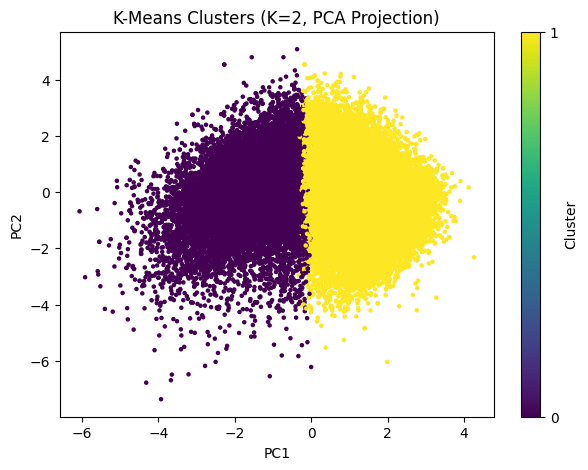

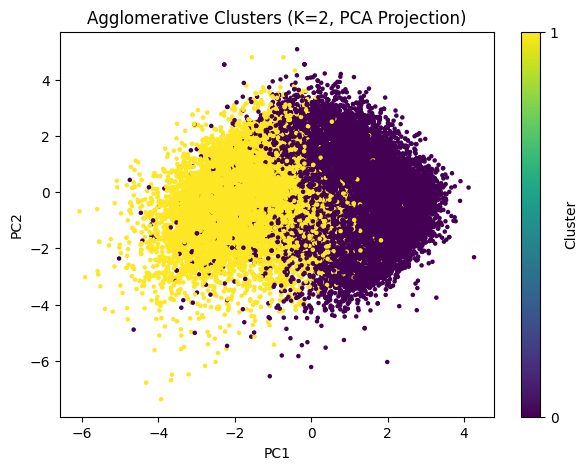

In [45]:
print(f"Fitting final KMeans model with K={optimal_k_kmeans}...")
kmeans_final = KMeans(n_clusters=optimal_k_kmeans, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled_cleaned)

print(f"Fitting final Agglomerative model with K={optimal_k_agglo}...")
agglo_final = AgglomerativeClustering(n_clusters=optimal_k_agglo, linkage='ward')
agg_labels = agglo_final.fit_predict(X_scaled_cleaned)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_cleaned)

# K-Means visualization
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=5)
plt.title(f"K-Means Clusters (K={optimal_k_kmeans}, PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster', ticks=range(optimal_k_kmeans) if optimal_k_kmeans > 0 else [0])
plt.show()

# Agglomerative visualization
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', s=5)
plt.title(f"Agglomerative Clusters (K={optimal_k_agglo}, PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster', ticks=range(optimal_k_agglo) if optimal_k_agglo > 0 else [0])
plt.show()

In [46]:
clustered_features_df = features_for_clustering[~nan_rows].copy()

clustered_features_df["kmeans_cluster"] = kmeans_labels
clustered_features_df["agg_cluster"] = agg_labels

KMeans Cluster Centroids:
                danceability    energy       key  loudness      mode  \
kmeans_cluster                                                         
0                   0.716840  0.632494  5.090292 -7.279988  0.594807   
1                   0.577888  0.865688  5.592377 -5.819103  0.513481   

                speechiness  acousticness  instrumentalness  liveness  \
kmeans_cluster                                                          
0                  0.200468      0.187883          0.042951  0.184458   
1                  0.085850      0.023379          0.473563  0.237583   

                 valence       tempo    duration_ms  time_signature  \
kmeans_cluster                                                        
0               0.450470  151.709210  191965.848053        3.970562   
1               0.283013  144.113475  297602.800831        3.974182   

                agg_cluster  
kmeans_cluster               
0                  0.871507  
1                

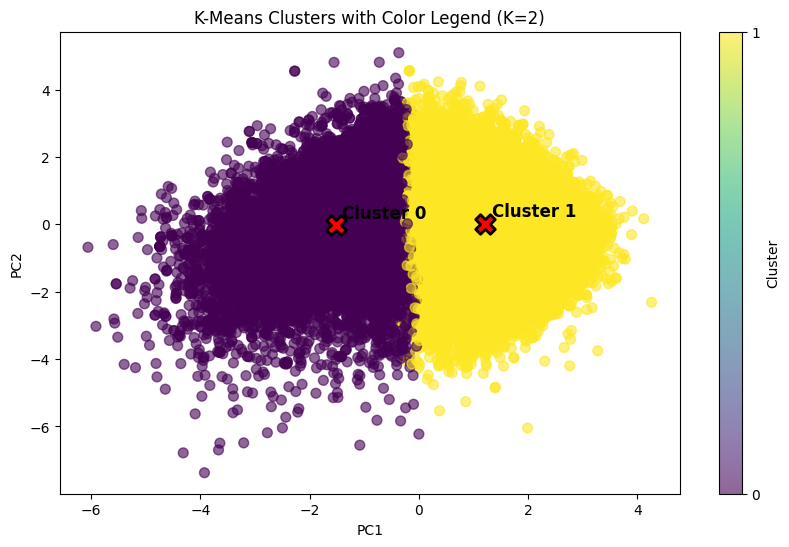


Cluster Sizes:
kmeans_cluster
0    18717
1    23588
Name: count, dtype: int64


In [47]:
# get centroids from the df with clusters, which is now correctly cleaned
df_centroids = clustered_features_df.groupby("kmeans_cluster").mean()
print("KMeans Cluster Centroids:")
print(df_centroids)

# to see which color corresponds to each cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.6)
plt.colorbar(scatter, label='Cluster', ticks=range(optimal_k_kmeans) if optimal_k_kmeans > 0 else [0])
plt.title(f"K-Means Clusters with Color Legend (K={optimal_k_kmeans})")
plt.xlabel("PC1")
plt.ylabel("PC2")

# annotate cluster centers on the plot
kmeans_final_centers_pca = pca.transform(kmeans_final.cluster_centers_)
for i, center in enumerate(kmeans_final_centers_pca):
    plt.scatter(center[0], center[1], c='red', marker='X', s=200, edgecolors='black', linewidths=2)
    plt.annotate(f'Cluster {i}', (center[0], center[1]), fontsize=12, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')

plt.show()
print("\nCluster Sizes:")
print(clustered_features_df["kmeans_cluster"].value_counts().sort_index())

In [50]:
kmeans_silhouette = silhouette_score(X_scaled_cleaned, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X_scaled_cleaned, kmeans_labels)

print(f"\n{'='*50}")
print(f"K-Means Clustering Metrics (K={optimal_k_kmeans})")
print(f"{'='*50}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_dbi:.4f}")

# calculate metrics for Agglomerative Clustering
agg_silhouette = silhouette_score(X_scaled_cleaned, agg_labels)
agg_dbi = davies_bouldin_score(X_scaled_cleaned, agg_labels)

print(f"\n{'='*50}")
print(f"Agglomerative Clustering Metrics (K={optimal_k_agglo})")
print(f"{'='*50}")
print(f"Silhouette Score: {agg_silhouette:.4f}")
print(f"Davies-Bouldin Index: {agg_dbi:.4f}")

#  comparison
print(f"\n{'='*50}")
print(f"Model Comparison")
print(f"{'='*50}")
print(f"{'Metric':<25} {'K-Means':<15} {'Agglomerative':<15}")
print(f"{'-'*55}")
print(f"{'Silhouette Score':<25} {kmeans_silhouette:<15.4f} {agg_silhouette:<15.4f}")
print(f"{'Davies-Bouldin Index':<25} {kmeans_dbi:<15.4f} {agg_dbi:<15.4f}")



K-Means Clustering Metrics (K=2)
Silhouette Score: 0.1363
Davies-Bouldin Index: 2.1622

Agglomerative Clustering Metrics (K=2)
Silhouette Score: 0.1200
Davies-Bouldin Index: 2.6246

Model Comparison
Metric                    K-Means         Agglomerative  
-------------------------------------------------------
Silhouette Score          0.1363          0.1200         
Davies-Bouldin Index      2.1622          2.6246         


# Final Model Summary (clustering section)


## 1. Preprocessing
- Loaded genres.csv and removed irrelevant identifiers (id, uri, track_href analysis_url, song_name, title, etc.).
- Dropped the  'Unnamed: 0' column.
- Selected only numerical Spotify audio features (danceability, energy, loudness, valence, tempo, instrumentalness, etc.).
- Verified no missing values.
- Standardized all features using StandardScaler


## 2. Feature Engineering
- No synthetic features added.
- Final feature set was around 42,000 entires of user data
- PCA used only for visualization (not for training).


## 3. Model Training & Results
Two clustering algorithms were tested:
- K-Means
- Agglomerative Clustering

Optimal k = 2 based on elbow method. (* this varies depending on the runtime type )


Metrics (k = 2):
- K-Means: Silhouette = 0.1487, DBI = 2.1622
- Agglomerative: Silhouette = 0.1200, DBI = 2.6246

Best Model: K-Means, due to better separation and lower DBI.

## 4. Cluster Highlights (K-Means, k=2)
- Cluster 0 — Vocal / Dance-Oriented
High danceability & speechiness
Moderate energy, higher valence
Low instrumentalness
Shorter durations
General Interpretation: upbeat, vocal-heavy music (Pop, Hip-Hop, mainstream EDM)


- Cluster 1 — Instrumental / High-Energy Production
Extremely high instrumentalness
Very high energy
Lower valence & danceability
Long track durations
General Interpretation: instrumental electronic, techno/trance, cinematic/ambient styles


## 5. User Segmentation Implications
- Cluster 0 listeners likely prefer catchy, vocal, rhythm-driven songs—good for party playlists, workouts, mainstream recommendations.

- Cluster 1 listeners may enjoy long-form, atmospheric, or instrumental tracks—ideal for focus playlists, electronic subgenres, or mood-based listening.


These clusters form the basis of a recommendation system that can tailor suggestions based on whether a user gravitates toward vocal/dance music or instrumental/production-heavy tracks. If we wanted ot extend this project we could use a sample row of data from a user and check where they might fall in the clusters.